<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/07wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-wS_yeeFPpsgM7ePyVx36bO&si=OxmV3QBEB3J7cyK2>}}

# 2. Imports

In [4]:
import torch
import torchvision
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. 신경망의 표현

신경망의 표현: ${\bf X} \to \hat{\bf Y}$ 로 가는 과정을 그림으로 표현

## A. 로지스틱

$$\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,1)}{\bf U} \overset{sig}{\to} \underset{(n,1)}{\bf V} =\underset{(n,1)}{\hat{\bf Y}}$$

**참고: 코드로 표현**

```Python
torch.nn.Sequential(
    torch.nn.Linear(1,1),
    torch.nn.Sigmoid()
)
```

`-` 모든 observation과 가중치를 명시한 버전

**(표현1)**

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-01.svg?raw=1)

- 단점: 똑같은 그림의 반복이 너무 많음

`-` observation 반복을 생략한 버전들

**(표현2)** 모든 $i$에 대하여 아래의 그림을 반복한다고 하면 (표현1)과 같다.

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-02.svg?raw=1)

**(표현3)** 그런데 (표현2)에서 아래와 같이 $x_i$, $y_i$ 대신에 간단히 $x$, $y$로 쓰는 경우도 많음

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-03.svg?raw=1)

`-` 1을 생략한 버전들

**(표현4)** bais=False 대신에 bias=True를 주면 1을 생략할 수 있음

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-04.svg?raw=1)

**(표현4의 수정)** $\hat{w}_1$대신에 $\hat{w}$를 쓰는 것이 더 자연스러움

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-05.svg?raw=1)

**(표현5)** 선형변환의 결과는 아래와 같이 $u$로 표현하기도 한다.

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-06.svg?raw=1)

> 다이어그램은 그리는 사람의 취향에 따라 그리는 방법이 조금씩 다릅니다. 즉 교재마다 달라요.

## B. 스펙의역설

$$\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,2)}{\bf U^{(1)}} \overset{relu}{\to} \underset{(n,2)}{\bf V^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\bf U^{(2)}} \overset{sig}{\to} \underset{(n,1)}{\bf V^{(2)}} =\underset{(n,1)}{\hat{\bf Y}}$$

**참고: 코드로 표현**

```Python
torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=2),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=2,out_features=1),
    torch.nn.Sigmoid()
)
```

`-` 이해를 위해서 예젠에 다루었던 아래의 상황을 고려하자.

![](https://guebin.github.io/DL2024/posts/03wk-2_files/figure-html/cell-11-output-1.png)

**(강의노트의 표현)**

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-07.svg?raw=1)

**(좀 더 일반화된 표현)** 상황을 일반화하면 아래와 같다.

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-08.svg?raw=1)

`*` Layer의 개념: ${\bf X}$에서 $\hat{\bf Y}$로 가는 과정은 "선형변환+비선형변환"이 반복되는 구조이다. "선형변환+비선형변환"을 하나의 세트로 보면 아래와 같이 표현할 수 있다.

- $\underset{(n,1)}{\bf X}  \overset{l_1}{\to} \left( \underset{(n,2)}{\bf U^{(1)}} \overset{relu}{\to} \underset{(n,2)}{\bf V^{(1)}} \right) \overset{l_2}{\to} \left(\underset{(n,1)}{\bf U^{(2)}} \overset{sig}{\to} \underset{(n,1)}{\bf V^{(2)}}\right), \quad  \underset{(n,1)}{\bf V^{(2)}}=\underset{(n,1)}{net({\bf X})}=\underset{(n,1)}{\hat{\bf Y}}$

이것을 다이어그램으로 표현한다면 아래와 같다.

**(선형+비선형을 하나의 Layer로 묶은 표현)**

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-09.svg?raw=1)

`-` node의 개념: $u\to v$로 가는 쌍을 간단히 노드라는 개념을 이용하여 나타낼 수 있음.

**(노드의 개념이 포함된 그림)**

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-10.svg?raw=1)

여기에서 `node의 숫자 = feature의 숫자`와 같이 이해할 수 있다. 즉 아래와 같이 이해할 수 있다.

**("number of nodes = number of features"로 이해한 그림)**

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-11.svg?raw=1)

> 다이어그램의 표현방식은 교재마다 달라서 모든 예시를 달달 외울 필요는 없습니다. 다만 임의의 다이어그램을 보고 대응하는 네트워크를 pytorch로 구현하는 능력은 매우 중요합니다.

## C. 이상한 취업률 곡선

$$\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,512)}{\bf U^{(1)}} \overset{relu}{\to} \underset{(n,512)}{\bf V^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\bf U^{(2)}} \overset{sig}{\to} \underset{(n,1)}{\bf V^{(2)}} =\underset{(n,1)}{\hat{\bf Y}}$$

**참고: 코드로 표현**

```Python
torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=512),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=512,out_features=1),
    torch.nn.Sigmoid()
)
```

`-` 그림으로 표현하면 아래와 같다.

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-12.svg?raw=1)

## D. 2024년수능30번

$$\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,512)}{\bf U^{(1)}} \overset{relu}{\to} \underset{(n,512)}{\bf V^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\bf U^{(2)}} =\underset{(n,1)}{\hat{\bf Y}}$$

**참고: 코드로 표현**

```Python
torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=512),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=512,out_features=1),
)
```

`-` 그림으로 표현하면 아래와 같다.

![](https://github.com/guebin/DL2026/blob/master/posts/07wk-fig-13.svg?raw=1)

> 포인트: (다이어그램, 코드, 수식) 을 셋트로 잘 기억할 것.

# 4. 레이어

## A. 레이어를 세는 방법

`-` Layer의 기준: 변환전후의 상태를 기준으로 하느냐?? 아니면 변환자체를 기준으로 하느냐??

- 다이어그램을 상상하면 변환전후의 "상태"를 layer로 보는 것이 자연스러워 보이고, 코드를 상상하면 "변환자체"를 layer로 보는것이 자연스러워 보인다.
- 놀랍게도 위의 질문에 대한 답은 "모두 다 layer라고 말함" 이다.  

`-` Layer를 세는 방법:

- 제 방식: 학습가능한 파라메터가 몇층으로 있는지 따지는 방식
- 다른방식1(상태): 상태를 기준으로 층을 센다. 단 activation layer 전후는 하나의 상태로 취급한다. 그리고 입력층은 count하지 않는다.
- 다른방식2(변환): 변환기준으로 층을 세고, activation layer는 count하지 않는다.



`-` Hidden Layer를 세는 방법:

- 제 방식: Hidden Layer의 수 = Layer수 - 1
- 일부교재설명: Layer의 수 = Hidden Layer의 수 + 출력층의 수

## B. 예시


```Python
# 예시1 -- 2층 (히든레이어는 1층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU(),
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
)
```

```Python
## 예시2 -- 2층 (히든레이어는 1층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU(),
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid(),
)
```

```Python
## 예시3 -- 1층 (히든레이어는 없음!!)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
)
```

```Python
## 예시4 -- 1층 (히든레이어는 없음!!)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
)
```

```Python
## 예시5 -- 3층 (히든레이어는 2층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층    
)
```



## C. 참고사항

`-` 참고1: 문헌에 따라서 레이어를 세는 개념이 제가 설명한 방식과 다른경우가 있습니다. 제가 설명한 방식보다 1씩 더해서 셉니다. 즉 아래의 경우 레이어를 3개로 카운트합니다.

```Python
## 예시1 -- 문헌에 따라 3층으로 세는 경우가 있음 (히든레이어는 1층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU(),
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
)
```

예를 들어 [여기](https://en.wikipedia.org/wiki/Multilayer_perceptron#Layers)에서는 위의 경우 레이어는 3개라고 설명하고 있습니다. 이러한 카운팅은 **"무시"하세요. 제가 설명한 방식이 맞아요.** [이 링크](https://en.wikipedia.org/wiki/Multilayer_perceptron#Layers) 잘못(?) 나와있는 이유는 아래와 같습니다.

- 진짜 예전에 MLP를 소개할 초창기에서는 위의 경우 Layer를 3개로 셌음. [@rosenblatt1962principles]
- 그런데 시간이 지나면서 어느순간 그렇게 안세기 시작함..

참고로 히든레이어의 수는 예전방식이나 지금방식이나 동일하게 카운트하므로 히든레이어만 세면 혼돈이 없습니다.

`-` 참고2: 사실 학습가능한 layer만 층으로 세는 방식이 젤 좋다고 생각하는데요, 이것도 예외가 있습니다. 이 강의에서 다루지 않을것같지만 BN계층이라는게 있는데요, 이건 학습가능한 파라메터가 있지만 layer로 취급하지 않습니다.

> AI의 답변: 일반적으로 딥러닝에서 신경망의 깊이나 전체 층(Layer) 수를 셀 때 BN 층은 독립적인 하나의 층으로 카운트하지 않는 경우가 대부분입니다. 그 이유는 다음과 같습니다.
>
> - 하나의 '세트(Block)'로 취급: 실무나 논문에서는 보통 [Conv(또는 Linear) $\rightarrow$ BN $\rightarrow$ Activation] 이 세 가지 연산을 하나로 묶어서 단일한 층이나 블록으로 간주합니다. BN은 새로운 특징을 추출한다기보다, 앞선 가중치 연산의 결과를 학습하기 좋게 다듬어주는 '보조적인 정규화 단계'로 인식하기 때문입니다.
> - 주요 가중치(Weight) 연산 기준: ResNet-50이나 VGG-16 등 유명한 모델의 이름에 붙은 숫자(층 수)를 셀 때는, 공간적/의미적 특징을 변환하는 핵심 연산 층(Convolutional Layer, Fully Connected Layer 등)만을 기준으로 셉니다.
>
> 요약하자면: "학습 가능한 파라미터가 있는 층을 센다"는 기준은 기본 신경망 구조를 이해하기 위한 가장 핵심적인 원칙이 맞습니다. 다만, BN처럼 모델을 돕기 위해 추가된 특수 목적의 층들은 파라미터가 있더라도 "주요 연산 층에 딸린 부속 층"으로 취급되어 전체 층 수(Depth)를 말할 때는 생략하는 것이 업계의 암묵적인 관례입니다.

`-` 제 생각을 정리: 레이어를 세는 방식은 레이어를 (1) 변환자체를 기준으로 생각할지 (2) 변환전후의 상태를 기준으로 생각할지에 따라 다름. 그런데 최근에는 변환자체를 기준으로 생각하는 추세임. 그래서 우리도 변환자체를 레이어라고 생각하는것이 좋겠음. 그런데 변환도 두가지 종류가 있는데 (1) 주변환과 (2) 보조변환이 있음. 주변환 같은 경우는 학습해야할 파라메터가 있고 주된 feature를 뽑아내는 역할을 함. 보조변환같은 경우는 주변환을 도와주는 역할을 수행함. 그런데 layer을 셀때는 주변환만 count를 함 (왜냐하면 보조변환은 주변환과 묶어서 하나로 취급하기 때문). 이때 주변환과 보조변환을 개념적으로 구분해야함. (이것을 쉽게 구분하는 툴은 "학습가능한 파라메터가 있냐?"를 따지는 것인데 이 툴도 완벽하지는 않음. BN이라는 예외가 있음)

# 5. 시벤코의 정리

`# Universal Approximation Thm`

하나의 은닉층을 가지는 아래와 같은 꼴의 네트워크는

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(p,512),
    torch.nn.ReLU(), # 원래버전은 여기에 torch.nn.Sigmoid()
    torch.nn.Linear(512,q),
)
```

모든 보렐가측함수^[그냥 우리가 상상하는 어지간한 함수는 다 된다고 생각하자.]

$$f: {\bf X}_{n\times p} \to {\bf Y}_{n \times q}$$

를 원하는 정확도로 "근사"시킬 수 있다. (노드숫자를 키울수록 더 정확하게 근사됨)

> 보렐가측함수라는것이 너무 궁금하면 <https://guebin.github.io/SS2024/> 를 참고해보세요.

`#`

`-` 시벤코정리를 이용하면 아래와 같은 일이 가능하다.

- ${\bf X}_{n\times 2}$는 토익점수와 GPA를 나타내는 행렬이고 ${\bf Y}_{n \times 1}$는 취업여부를 의미하는 행렬일때 ${\bf X} \to {\bf Y}$인 규칙을 하나의 은닉층을 가지는 net가 항상 근사할 수 있다. (충분히 노드수를 키운다면)
- ${\bf X}_{n \times p}$는 주택면적, 지역정보, 주택이미지, 주택에대한 설명을 숫자화시켜 정리한 행렬이고, ${\bf Y}_{n\times 1}$는 주택가격일 경우 ${\bf X} \to {\bf Y}$인 규칙을 하나의 은닉층을 가진 net가 항상 근사 할 수 있다. (충분히 노드수를 키운다면)

`-` 증명에 대한 아이디어는 예전강의노트를 참고.

- <https://guebin.github.io/DL2025/posts/04wk-2.html#b.-%EC%99%9C-%EA%B0%80%EB%8A%A5%ED%95%9C%EA%B0%80>

# 6. XOR

## A. (그 유명한) XOR 문제

`-` 아래의 자료를 적합시키는 네트워크를 설계하여 보자.

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0  |

## B. 풀이1(실패) -- Quiz11-4번문제

In [43]:
def sig(x):
    return torch.exp(x) / (torch.exp(x) + 1)

x1 = torch.tensor([0.0, 0.0, 1.0, 1.0])
x2 = torch.tensor([0.0, 1.0, 0.0, 1.0])
y = torch.tensor([0.0, 1.0, 1.0, 0.0])
X = torch.stack([torch.ones(4), x1,x2],axis=1)
Y = y.reshape(-1, 1)

torch.manual_seed(42)
What = torch.randn((3,1), requires_grad=True)
#---#
for epoch in range(1000):
    Yhat = sig(X @ What)
    loss = -torch.mean(Y*torch.log(Yhat) + (1-Y)*torch.log(1-Yhat))
    loss.backward()
    What.data = What.data - 0.001 * What.grad
    What.grad = None

In [44]:
What

tensor([[0.2313],
        [0.0703],
        [0.1698]], requires_grad=True)

In [47]:
for epoch in range(1000):
    Yhat = sig(X @ What)
    loss = -torch.mean(Y*torch.log(Yhat) + (1-Y)*torch.log(1-Yhat))
    loss.backward()
    What.data = What.data - 0.1 * What.grad
    What.grad = None

In [48]:
What

tensor([[ 4.5635e-06],
        [-4.0286e-06],
        [-3.6689e-06]], requires_grad=True)

- [0,0,0] 으로 수렴한듯

`-` 잘 적합되었는지 확인해보자.

In [52]:
sig(X@What), Y

(tensor([[0.5000],
         [0.5000],
         [0.5000],
         [0.5000]], grad_fn=<DivBackward0>),
 tensor([[0.],
         [1.],
         [1.],
         [0.]]))

- 적합이 제대로 되지 않았다.
- 왜??

`-` 분석: 주어진 데이터를 학습하기에는 아래 네트워크의 표현력이 부족하다.

$$y_i \approx \hat{y}_i = \text{sig}(\hat{w}_0 + \hat{w}_1 x_{i1} + \hat{w}_2 x_{i2})$$

- $\hat{w}_0$값이 크게 학습된다면 전체적으로 $\hat{y}_i$의 값이 1이 되도록 학습된다.
- $\hat{w}_1$값이 크게 학습된다면 $\hat{x}_{i1}$의 값에 비례하여 $\hat{y}_i$이 1이 되도록 학습된다.
- $\hat{w}_2$값이 크게 학습된다면 $\hat{x}_{i2}$의 값에 비례하여 $\hat{y}_i$이 1이 되도록 학습된다.

`-` 만약에 데이터가 이렇게 생겼더라면..

(예시1)

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1  |

(예시2)

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 1 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0  |

(예시3)

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 0 | 1 |
| 0 | 1 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |
| 1 | 1 | 1 |

## C. 풀이2(성공) -- 시벤코정리

`-` ${\bf x}_1$은 학점, ${\bf x}_2$를 토익점수 ${\bf y}$를 취업여부라고 상상한다면?

- 데이터가 말하는 건 ${\bf x}_1$이랑 ${\bf x}_2$가 모두 큰데 오히려 취업이 안되는 상황
- 풀이1이 실패했던건 표현력이 부족했기 때문

In [122]:
x1 = torch.tensor([0.0, 0.0, 1.0, 1.0])
x2 = torch.tensor([0.0, 1.0, 0.0, 1.0])
y = torch.tensor([0.0, 1.0, 1.0, 0.0])
X = torch.stack([x1,x2],axis=1)
Y = y.reshape(-1, 1)
torch.manual_seed(42)
net = torch.nn.Sequential(
    torch.nn.Linear(2,512,bias=True), # 레이어통과후 shape:(n,512)
    torch.nn.ReLU(), # 레이어통과후 shape: (n,512)
    torch.nn.Linear(512,1,bias=True), # 레이어통과후 shape: (n,1)
    torch.nn.Sigmoid() # 레이어통과후 shape: (n,1)
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters(),lr=0.001)
#---#
for epoch in range(1000):
    Yhat = net(X)
    loss = loss_fn(Yhat,Y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [123]:
net(X).data

tensor([[0.0012],
        [0.9988],
        [0.9988],
        [0.0012]])

# 7. 전통적 모델링 vs 딥러닝식 모델링

## A. 자유낙하 문제

`-` 박혜원씨는 물체가 떨어진 높이와 물체가 지면에 떨어지는 시간이 어떠한 관계가 있다는 것을 알았다. 구체적으로

> 높은곳에서 떨어진 물체일수록 더 오랜시간 낙하함.

와 같은 관계가 있다는 사실을 알았다.

In [124]:
height = [
    0.1867,  0.2848,  2.1355,  2.2167,  4.1491,  8.1850,  8.7433,  9.3315,
    14.5883, 14.9888, 16.5491, 17.7069, 18.8424, 21.8355, 21.8808, 22.0881,
    22.3026, 22.5745, 23.1269, 23.9332, 24.6669, 27.2351, 27.4392, 27.6720,
    28.1114, 29.1729, 29.2594, 30.6107, 30.7007, 31.9626, 32.4375, 33.5212,
    33.8969, 35.3980, 35.4875, 36.0210, 36.7319, 37.2270, 37.7999, 37.9642,
    38.5938, 39.0878, 39.3041, 39.5966, 41.6302, 43.3391, 43.4646, 43.4779,
    44.2029, 44.5496, 45.1828, 47.0924, 47.5687, 48.3803, 49.7113, 49.9602,
    50.4318, 50.5070, 50.5837, 51.3863, 51.3869, 52.9359, 53.6882, 54.3114,
    56.0177, 60.8485, 62.5412, 64.0429, 64.4687, 65.6608, 65.7108, 67.0237,
    67.1796, 68.4925, 69.4765, 70.7629, 71.0061, 71.1954, 71.3918, 74.0178,
    77.3426, 77.5536, 78.2571, 79.4971, 79.6985, 80.0267, 80.4075, 83.2470,
    84.7562, 85.1897, 85.7150, 87.1619, 90.8313, 91.7407, 92.3853, 93.5739,
    96.1382, 96.9394, 99.0074, 99.6843
]

In [125]:
fall_time = [
    0.0612, 0.1882, 0.7556, 0.6769, 0.9018, 1.3658, 1.4047, 1.2397, 1.8347,
    1.7617, 1.8318, 1.7867, 1.9896, 2.0901, 2.0347, 2.0704, 2.1524, 2.1035,
    2.1703, 1.9836, 2.3152, 2.3836, 2.4949, 2.3455, 2.5333, 2.2178, 2.4416,
    2.5534, 2.6200, 2.6332, 2.5955, 2.5901, 2.5771, 2.8369, 2.7254, 2.7138,
    2.7489, 2.7782, 2.7200, 2.7547, 2.6128, 2.8415, 2.7808, 2.6488, 3.1167,
    3.0383, 2.9401, 3.0126, 2.9233, 3.1341, 3.0755, 2.9978, 3.1484, 3.1864,
    3.3868, 3.2313, 3.1209, 3.1922, 3.2119, 3.1101, 3.3041, 3.3947, 3.1918,
    3.4043, 3.3920, 3.4561, 3.7133, 3.5496, 3.6964, 3.7211, 3.5275, 3.7168,
    3.6911, 3.6120, 3.8650, 3.9209, 3.7195, 3.9642, 3.8094, 3.9951, 4.2356,
    3.9031, 3.8805, 3.8605, 4.1031, 3.9385, 4.0645, 4.2283, 4.1582, 4.1910,
    4.0181, 4.2427, 4.4362, 4.4256, 4.4554, 4.4870, 4.4486, 4.4710, 4.4710,
    4.4741
]

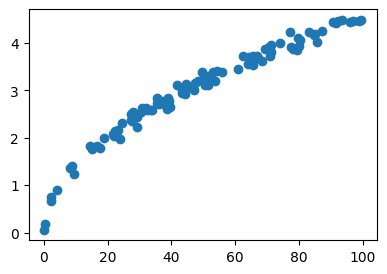

In [127]:
plt.plot(height,fall_time,'o')

만약에 높이 50m에서 떨어뜨리면, 몇초만에 떨어질까?

## B. 풀이1 -- 전통적모델링

`-` 그래프를 보면 높이가 높을 수록 낙하시간도 길어지는 경향이 보임.

- 다만 동일한 높이라 하더라도 낙하시간이 조금씩 차이가 날 수 있어보임.
- 이는 사람이 시간측정을 수동으로 하며 발생하는 실험오차 떄문인것 같음.

`-` 아무튼 오차에도 불구하고 `height`와 `fall_time`은 일정한 규칙이 존재(=오차랑 관련없는 underlying structure)하는 것 같음.

`-` **자문요청**: 물리학과 교수님께 자문을 요청한 결과

$$\text{자유낙하시간} \propto \sqrt{\text{높이}}$$

`-` 자문결과를 근거로 아래와 같은 모형을 설계하였다.

$$t_i = w_1^{\ast} \sqrt{h_i} + \epsilon_i, \quad \epsilon_i \sim N(0,??)$$

`-` $y_i=t_i$로 $x_i = \sqrt{h_i}$로 해석하면? 회귀모형으로 볼 수 있다!

In [133]:
X = torch.sqrt(torch.tensor(height)).reshape(-1,1)
Y = torch.tensor(fall_time).reshape(-1,1)

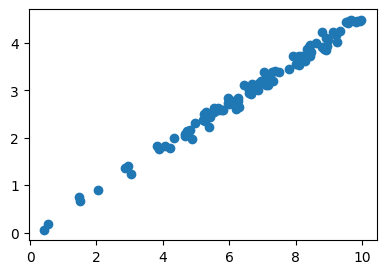

In [136]:
plt.plot(X,Y,'o') # 적당한 변환을 샥샥하니까... 회귀문제네??

In [140]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(1,1,bias=False)
)
# net = torch.nn.Linear(1,1,bais=False)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(100):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [180]:
for epoch in range(100):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

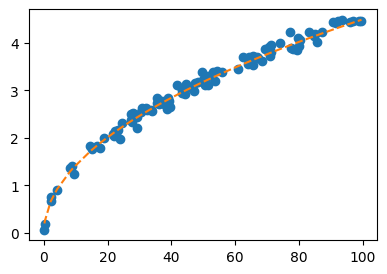

In [181]:
#plt.plot(height,fall_time,'o')
plt.plot(X**2,Y,'o')
plt.plot(X**2,net(X).data,'--')

`-` 예측: 만약 높이 50m에서 떨어뜨리면 몇초만에 떨어질까?

In [183]:
list(net.parameters())

[Parameter containing:
 tensor([[0.4499]], requires_grad=True)]

In [187]:
0.4499 * torch.sqrt(torch.tensor(50))

tensor(3.1813)

In [194]:
Xnew = torch.sqrt(torch.tensor([[50]]))
net(Xnew).data

tensor([[3.1811]])

## C. 풀이2 -- 딥러닝식 모델링

`-` 참모델? 관심없음

`-` 그냥 딥러닝식 무지성적합 (underlying structure가 뭔지 알게 뭐야)

In [197]:
X = torch.tensor(height).reshape(-1,1)
Y = torch.tensor(fall_time).reshape(-1,1)
# 천하무적 네트워크
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1),
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(100):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [213]:
for epoch in range(100):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

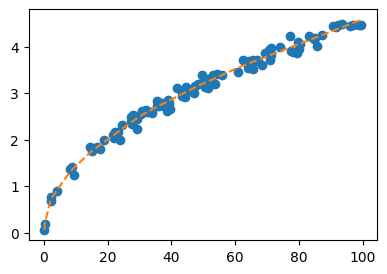

In [214]:
#plt.plot(height,fall_time,'o')
plt.plot(X,Y,'o')
plt.plot(X,net(X).data,'--')

In [215]:
Xnew = torch.tensor([[50.00]])
net(Xnew).data

tensor([[3.2052]])

- 쓸만한데??

`-` true가 아니더라도 쓸만함..

> "All models are wrong (but some are useful)", George Box

ref: <https://en.wikipedia.org/wiki/All_models_are_wrong>

`-` 너무나 유명한 벤다이어그램 

ref: <https://www.geeksforgeeks.org/data-science/drew-conways-diagram-of-data-science/>

![](https://media.geeksforgeeks.org/wp-content/uploads/20201121195510/DataScienceVD.png)